Total Bonafide available: 2580
Total Spoof available: 22800
Final Dataset:
Bonafide: 2580
Spoof: 2580
Total: 5160
Total Bonafide available: 2548
Total Spoof available: 22296
Final Dataset:
Bonafide: 2548
Spoof: 2548
Total: 5096
Total Bonafide available: 7355
Total Spoof available: 63882
Final Dataset:
Bonafide: 7000
Spoof: 7000
Total: 14000
Epoch 1/8
Train Acc: 0.8465 | Val Acc: 0.9217
----------------------------------------
Epoch 2/8
Train Acc: 0.9746 | Val Acc: 0.9927
----------------------------------------
Epoch 3/8
Train Acc: 0.9917 | Val Acc: 0.9951
----------------------------------------
Epoch 4/8
Train Acc: 0.9932 | Val Acc: 0.9957
----------------------------------------
Epoch 5/8
Train Acc: 0.9948 | Val Acc: 0.9867
----------------------------------------
Epoch 6/8
Train Acc: 0.9983 | Val Acc: 0.9963
----------------------------------------
Epoch 7/8
Train Acc: 0.9981 | Val Acc: 0.9967
----------------------------------------
Epoch 8/8
Train Acc: 0.9969 | Val Acc: 0.9694
--

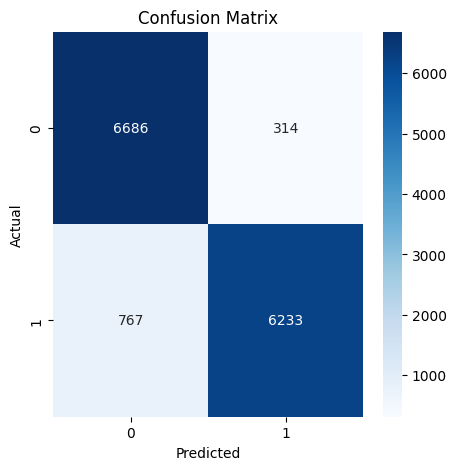

AUC Score: 0.9589824591836734


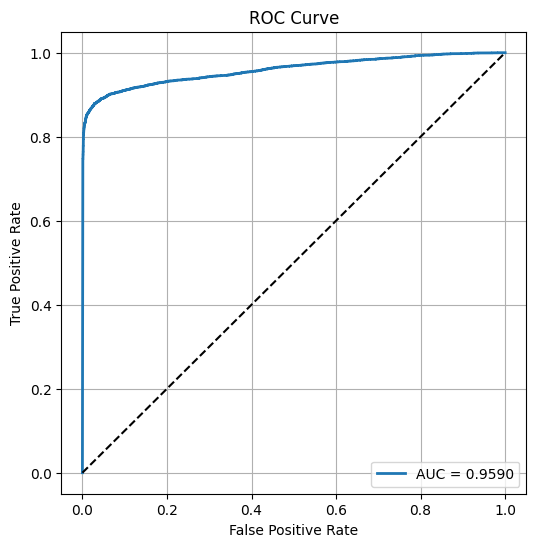

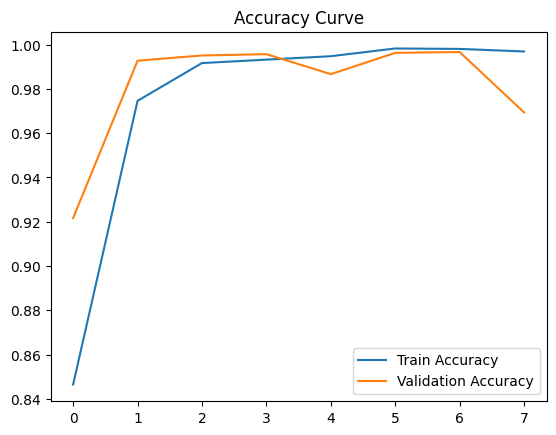

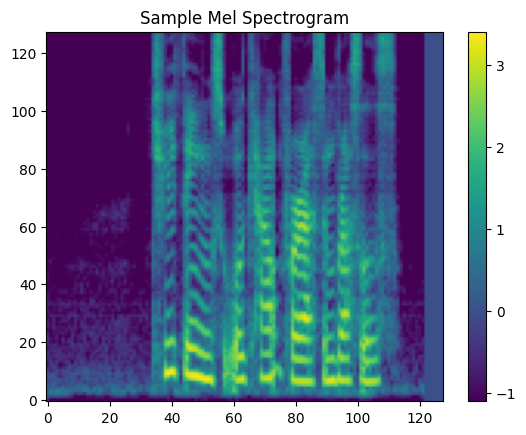

In [1]:
import os
import random
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
random.seed(42)

############################################################
# DATASET
############################################################

class ASVSpoofDataset(Dataset):
    def __init__(self, protocol_file, audio_dir, samples_per_class=7000):
        self.audio_dir = audio_dir
        self.file_list = []
        self.labels = []

        bonafide = []
        spoof = []

        # Read entire protocol
        with open(protocol_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            file_id = parts[1]
            label = parts[-1]

            if label == "bonafide":
                bonafide.append(file_id)
            else:
                spoof.append(file_id)

        print(f"Total Bonafide available: {len(bonafide)}")
        print(f"Total Spoof available: {len(spoof)}")

        # Ensure we don't exceed available samples
        samples_per_class = min(samples_per_class, len(bonafide), len(spoof))

        # Randomly sample
        bonafide = random.sample(bonafide, samples_per_class)
        spoof = random.sample(spoof, samples_per_class)

        selected = bonafide + spoof
        random.shuffle(selected)

        for file_id in selected:
            self.file_list.append(file_id + ".flac")
            if file_id in bonafide:
                self.labels.append(0)
            else:
                self.labels.append(1)

        print("Final Dataset:")
        print("Bonafide:", samples_per_class)
        print("Spoof:", samples_per_class)
        print("Total:", len(self.file_list))

    def __len__(self):
        return len(self.file_list)

    def extract_mel(self, file_path):
        y, sr = librosa.load(file_path, sr=16000)

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=128, n_fft=1024, hop_length=512
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize (IMPORTANT)
        mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

        if mel_db.shape[1] < 128:
            pad = 128 - mel_db.shape[1]
            mel_db = np.pad(mel_db, ((0, 0), (0, pad)))
        else:
            mel_db = mel_db[:, :128]

        return mel_db.astype(np.float32)

    def __getitem__(self, idx):
        file_path = os.path.join(self.audio_dir, self.file_list[idx])
        mel = self.extract_mel(file_path)
        mel = np.expand_dims(mel, axis=0)
        label = self.labels[idx]
        return torch.tensor(mel), torch.tensor(label, dtype=torch.float32)
############################################################
# MODEL
############################################################

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = x.mean(dim=(2,3))
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class CNN_Attention(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.attention = SEBlock(128)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),  # stronger dropout
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.classifier(x)
        return x

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.classifier(x)
        return x

    def forward(self, x):
        x = self.features(x)
        x = self.attention(x)
        x = self.classifier(x)
        return x

############################################################
# TRAINING
############################################################

def train_model(model, train_loader, val_loader, epochs=8):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        all_preds = []
        all_labels = []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x).squeeze()
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            preds = torch.sigmoid(outputs) > 0.5
            all_preds.extend(preds.cpu().detach().numpy())
            all_labels.extend(y.cpu().detach().numpy())

        train_acc = accuracy_score(all_labels, all_preds)

        val_acc = evaluate(model, val_loader)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print("-"*40)

    return train_accs, val_accs


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x).squeeze()
            preds = torch.sigmoid(outputs) > 0.5

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    return accuracy_score(all_labels, all_preds)

############################################################
# PATHS
############################################################

ROOT = "/kaggle/input/asvpoof-2019-dataset/LA/LA"

train_protocol = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol   = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
eval_protocol  = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")

train_audio = os.path.join(ROOT, "ASVspoof2019_LA_train/flac")
dev_audio   = os.path.join(ROOT, "ASVspoof2019_LA_dev/flac")
eval_audio  = os.path.join(ROOT, "ASVspoof2019_LA_eval/flac")

############################################################
# LOAD DATA (3000 EACH)
############################################################

train_dataset = ASVSpoofDataset(train_protocol, train_audio)
val_dataset   = ASVSpoofDataset(dev_protocol, dev_audio)
test_dataset  = ASVSpoofDataset(eval_protocol, eval_audio)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

############################################################
# TRAIN
############################################################

model = CNN_Attention().to(device)
train_accs, val_accs = train_model(model, train_loader, val_loader)

############################################################
# TEST METRICS
############################################################

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x).squeeze()
        probs = torch.sigmoid(outputs)
        preds = probs > 0.5

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("\nTEST METRICS")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

############################################################
# CONFUSION MATRIX
############################################################

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

############################################################
# ROC + AUC
############################################################

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("roc_curve.png", dpi=300)
plt.show()

############################################################
# TRAINING CURVE
############################################################

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

############################################################
# SAMPLE MEL SPECTROGRAM
############################################################

sample_x, _ = train_dataset[0]
plt.imshow(sample_x.squeeze(), aspect='auto', origin='lower')
plt.title("Sample Mel Spectrogram")
plt.colorbar()
plt.show()

In [2]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Compute EER
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
fnr = 1 - tpr

eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
eer_threshold = interp1d(fpr, thresholds)(eer)

print("EER:", eer)

EER: 0.09200000000013805
